In [1]:
import numpy as np 
import pandas as pd
import os
from readData import *
from baryonFit import HernquistFit

import matplotlib.pyplot as plt

# Get all galaxy ids

In [2]:
galaxy_ids = get_galaxy_ids()

# Generate all lmfit fits assuming gamma = 0.5

In [21]:
plot_path = os.getcwd() + "/plots/fits/"
data_path = os.getcwd() + "/data/fit_data/"

results = []
failed = []

for galaxy_id in galaxy_ids:
    try:
        fitter = HernquistFit(galaxy_id, gamma_star=0.5, method="lmfit")
        M_b_fit, a_fit = fitter.M_b_fit, fitter.a_fit
        chisqr = fitter.result.chisqr
        redchisqr = fitter.result.redchi
    except Exception as e:
        failed.append(galaxy_id)
        print(f"Error fitting galaxy {galaxy_id}. Skipping...")
        continue
    
    results.append([galaxy_id, M_b_fit, a_fit, chisqr, redchisqr])
    
    rmax = fitter.r_vals.max() * 2 # kpc
    r_vals = np.geomspace(0.1, rmax, 100)
    vc_fit = fitter.vc(r_vals)
    
    plt.figure(figsize=(6,4))
    plt.plot(r_vals, vc_fit, label='Hernquist Fit', color='C0', alpha=0.7, zorder=0)
    plt.errorbar(fitter.r_vals, fitter.vc_baryons, yerr=fitter.data["errV"], fmt='o', label='Data', color='k', zorder=1, markersize=4, alpha=0.5)
    plt.xlabel('Radius [kpc]')
    plt.ylabel('Circular Velocity [km/s]')
    plt.title(f'Galaxy {galaxy_id} Hernquist Fit')
    plt.legend()
    plt.savefig(os.path.join(plot_path, f"{galaxy_id}_hernquist_fit.png"))
    plt.close()
    
    
results_df = pd.DataFrame(results, columns=["GalaxyID", "M_b_fit", "a_fit", "ChiSq", "RedChiSq"])
results_df.to_csv(os.path.join(data_path, "hernquist_fit_results.csv"), index=False)
print("Fitting complete. Results saved.")
np.savetxt(os.path.join(data_path, "failed_fits.txt"), failed, fmt="%s")
    

Fitting with lmfit took 0.0110 seconds
Fitted parameters for galaxy NGC5371 using lmfit:
  M_b = 3.93e+11 solar masses
  a   = 10.53 kpc
  chi-squared = 6127.4849


Fitting with lmfit took 0.3429 seconds
Fitted parameters for galaxy UGC05829 using lmfit:
  M_b = 1.13e+21 solar masses
  a   = 5497424.38 kpc
  chi-squared = 185.9626
Fitting with lmfit took 0.0151 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 1.48e+11 solar masses
  a   = 2.37 kpc
  chi-squared = 2086.7819
Error fitting galaxy UGCA444 with lmfit: The model function generated NaN values and the fit aborted! Please check your model function and/or set boundaries on parameters where applicable. In cases like this, using "nan_policy='omit'" will probably not work.
Fitting with lmfit took 0.0034 seconds
Error fitting galaxy UGCA444. Skipping...
Fitting with lmfit took 0.0068 seconds
Fitted parameters for galaxy NGC1003 using lmfit:
  M_b = 1.22e+10 solar masses
  a   = 4.40 kpc
  chi-squared = 264.3338
Error fitting galaxy UGC07559 with lmfit: The model function generated NaN values and the fit aborted! Please check your model function and/or set boundaries on paramete

# Generate lmfit with Gamma Fits 

In [3]:
plot_path = os.getcwd() + "/plots/fits/"
data_path = os.getcwd() + "/data/fit_data/"

gamma_data = pd.read_csv(data_path + "gamma_fits.csv")

results = []
failed = []

for galaxy_id in galaxy_ids:
    gamma_s, gamma_b = gamma_data[gamma_data["GalaxyID"] == galaxy_id][["Gamma_disk", "Gamma_bulge"]].values[0]
    try:
        # Set gamma_bulge = 0 
        fitter = HernquistFit(galaxy_id, gamma_star=gamma_s, gamma_bulge=0.0, method="lmfit")
        M_b_fit, a_fit = fitter.M_b_fit, fitter.a_fit
        chisqr = fitter.result.chisqr
        redchisqr = fitter.result.redchi
    except Exception as e:
        failed.append(galaxy_id)
        print(f"Error fitting galaxy {galaxy_id}. Skipping...")
        continue
    
    results.append([galaxy_id, M_b_fit, a_fit, chisqr, redchisqr])
    
    rmax = fitter.r_vals.max() * 2 # kpc
    r_vals = np.geomspace(0.1, rmax, 100)
    vc_fit = fitter.vc(r_vals)
    
    # plt.figure(figsize=(6,4))
    # plt.plot(r_vals, vc_fit, label='Hernquist Fit', color='C0', alpha=0.7, zorder=0)
    # plt.errorbar(fitter.r_vals, fitter.vc_baryons, yerr=fitter.data["errV"], fmt='o', label='Data', color='k', zorder=1, markersize=4, alpha=0.5)
    # plt.xlabel('Radius [kpc]')
    # plt.ylabel('Circular Velocity [km/s]')
    # plt.title(f'Galaxy {galaxy_id} Hernquist Fit')
    # plt.legend()
    # plt.savefig(os.path.join(plot_path, f"{galaxy_id}_hernquist_fit.png"))
    # plt.close()
    
    
results_df = pd.DataFrame(results, columns=["GalaxyID", "M_b_fit", "a_fit", "ChiSq", "RedChiSq"])
results_df.to_csv(os.path.join(data_path, "hernquist_fit_disk_gas.csv"), index=False)
print("Fitting complete. Results saved.")
np.savetxt(os.path.join(data_path, "failed_fits_gamma.txt"), failed, fmt="%s")

Fitting with lmfit took 0.0211 seconds
Fitted parameters for galaxy NGC5371 using lmfit:
  M_b = 3.38e+11 solar masses
  a   = 10.72 kpc
  chi-squared = 5220.8497
Fitting with lmfit took 0.3205 seconds
Fitted parameters for galaxy UGC05829 using lmfit:
  M_b = 1.14e+21 solar masses
  a   = 5515868.85 kpc
  chi-squared = 182.8182
Fitting with lmfit took 0.0137 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 3.04e+11 solar masses
  a   = 7.39 kpc
  chi-squared = 1667.2293
Error fitting galaxy UGCA444 with lmfit: The model function generated NaN values and the fit aborted! Please check your model function and/or set boundaries on parameters where applicable. In cases like this, using "nan_policy='omit'" will probably not work.
Fitting with lmfit took 0.0086 seconds
Fitted parameters for galaxy UGCA444 using lmfit:
  M_b = nan solar masses
  a   = nan kpc
  chi-squared = nan
Error fitting galaxy UGCA444. Skipping...
Fitting with lmfit took 0.0056 seconds
Fitted parameters

# Generate lmfit with Gamma and Bulge 

In [3]:
bulge_list = []

for gal in galaxy_ids:
    df, _, _ = get_rc_data(gal)
    vbul = df.Vbul.values 
    
    if np.any(vbul > 0):
        bulge_list.append(gal)

print("Total number of galaxies:", len(galaxy_ids))
print("Number of galaxies with bulge component:", len(bulge_list))
print("Galaxies with bulge component:", bulge_list)

Total number of galaxies: 175
Number of galaxies with bulge component: 32
Galaxies with bulge component: ['NGC5005', 'NGC6195', 'UGC08699', 'NGC2841', 'NGC5985', 'UGC05253', 'UGC03546', 'NGC6946', 'UGC06614', 'NGC5033', 'UGC02885', 'UGC06973', 'UGC02487', 'NGC2683', 'NGC7814', 'UGC11914', 'NGC0891', 'UGC06787', 'NGC2955', 'UGC03580', 'UGC06786', 'NGC6674', 'UGC09133', 'UGC02953', 'NGC4138', 'IC4202', 'NGC4013', 'UGC03205', 'NGC7331', 'UGC02916', 'NGC4217', 'NGC4157']


In [3]:
plot_path = os.getcwd() + "/plots/fits/"
data_path = os.getcwd() + "/data/fit_data/"

gamma_data = pd.read_csv(data_path + "gamma_fits.csv")

results = []
failed = []

for galaxy_id in galaxy_ids: 
    gamma_s, gamma_b = gamma_data[gamma_data["GalaxyID"] == galaxy_id][["Gamma_disk", "Gamma_bulge"]].values[0]
    try:
        fitter = HernquistFit(galaxy_id, gamma_star=gamma_s, gamma_bulge=gamma_b, method="lmfit")
        M_b_fit, a_fit = fitter.M_b_fit, fitter.a_fit
        chisqr = fitter.error
        
        M_b_fit_b, a_fit_b = fitter.M_b_fit_bulge, fitter.a_fit_bulge
        chisqr_b = fitter.error_bulge
    except Exception as e:
        failed.append(galaxy_id)
        print(f"Error fitting galaxy {galaxy_id}. Skipping...")
        continue
    
    results.append([galaxy_id, M_b_fit, a_fit, chisqr, M_b_fit_b, a_fit_b, chisqr_b])
    
    # r_vals = fitter.r_vals
    # rmax = r_vals.max() * 2 # kpc
    # ri = np.geomspace(0.1, rmax, 100)
    
    # vc_dg_data = fitter.vc_disk_gas
    # vc_bulge_data = fitter.vc_bulge
    
    # vc_dg_model = fitter.vc(ri, M_b=M_b_fit, a=a_fit)
    # vc_bulge_model = fitter.vc(ri, M_b=M_b_fit_b, a=a_fit_b)
    
    
    # plt.figure(figsize=(6,4))

    # plt.scatter(r_vals, vc_dg_data, label='Disk+Gas', color='C0', s=10)
    # plt.plot(ri, vc_dg_model, label='Disk+Gas Hernquist', color='C0', alpha=0.7)
    # plt.scatter(r_vals, vc_bulge_data, label='Bulge', color='C1', s=10)
    # plt.plot(ri, vc_bulge_model, label='Bulge Hernquist', color='C1', alpha=0.7)
    # plt.xlabel('Radius (kpc)')
    # plt.ylabel('Velocity (km/s)')
    # plt.title(f'Hernquist Fit for Galaxy {galaxy_id}')
    # plt.legend(fontsize=6, loc="lower right")
    # plt.grid()
    # plt.savefig(plot_path + f"disk-bulge-gas/{galaxy_id}_disk_gas_bulge_fit.png")
    # plt.close()
    
    
results_df = pd.DataFrame(results, columns=["GalaxyID", "M_b_fit", "a_fit", "ChiSq", "M_b_fit_bulge", "a_fit_bulge", "ChiSq_bulge"])
results_df.to_csv(os.path.join(data_path, "hern-fits.csv"), index=False)
print("Fitting complete. Results saved.")
np.savetxt(os.path.join(data_path, "hern-failed.txt"), failed, fmt="%s")
print("Number of failed fits:", len(failed))

Fitting with lmfit took 0.0192 seconds
Fitted parameters for galaxy NGC5371 using lmfit:
  M_b = 3.38e+11 solar masses
  a   = 10.72 kpc
  chi-squared = 5220.8497
Fitting with lmfit took 0.0148 seconds
Fitted parameters for galaxy UGC05829 using lmfit:
  M_b = 5.88e+25 solar masses
  a   = 1252023733.21 kpc
  chi-squared = 182.8176
Fitting with lmfit took 0.0083 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 3.04e+11 solar masses
  a   = 7.39 kpc
  chi-squared = 1667.2293
Bulge component detected, performing separate fit for bulge...
Fitting with lmfit took 0.0157 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 1.50e+10 solar masses
  a   = 0.41 kpc
  chi-squared = 1970.0142
Fitting with lmfit took 0.0124 seconds
Fitted parameters for galaxy UGCA444 using lmfit:
  M_b = 6.69e+09 solar masses
  a   = 13.21 kpc
  chi-squared = 133.6809
Fitting with lmfit took 0.0062 seconds
Fitted parameters for galaxy NGC1003 using lmfit:
  M_b = 1.38e+10 solar masse

In [12]:
def phi(M_b, a):
    G = 4.30091e-6  # [kpc * (km/s)^2/ solar mass]

    def phi_func(r, th):
        return -G * M_b / (r + a)

    return phi_func

In [13]:
bulge_data = pd.read_csv(data_path + "hernquist_fits_disk_gas_bulge.csv")

bulge_ids = bulge_data["GalaxyID"].values

for bul in bulge_ids:
    sub = bulge_data[bulge_data["GalaxyID"] == bul]
    M_b_fit = sub["M_b_fit"].values[0]
    a_fit = sub["a_fit"].values[0]
    M_b_fit_bulge = sub["M_b_fit_bulge"].values[0]
    a_fit_bulge = sub["a_fit_bulge"].values[0]
    
    ri = np.geomspace(0.1, 200, 200)
    phi_dg = np.abs(np.array([phi(M_b_fit, a_fit)(r, 0) for r in ri]))
    phi_b  = np.abs(np.array([phi(M_b_fit_bulge, a_fit_bulge)(r, 0) for r in ri]))

    phi_total = phi_dg + phi_b

    percent_diff = 100 * ( np.abs((phi_total - phi_dg)) / np.abs(phi_total) )

    fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=True, gridspec_kw={'height_ratios': [3, 1]})


    axs[0].plot(ri, phi_dg, label='Disk+Gas Potential', color='C0')
    axs[0].plot(ri, phi_b, label='Bulge Potential', color='C1')
    axs[0].plot(ri, phi_total, label='Total Baryonic Potential', color='k', linestyle='--')
    axs[0].set_ylabel('-Potential (km^2/s^2)')
    axs[0].set_title(f'Gravitational Potential for Galaxy {bul}')
    axs[0].legend(fontsize=6, loc="lower left")
    axs[0].grid()
    axs[0].set_xscale('log')
    axs[0].set_yscale('log')

    axs[1].plot(ri, percent_diff, label='Percent Difference', color='k')
    axs[1].set_xlabel('Radius (kpc)')
    axs[1].set_ylabel('Diff (%)')
    axs[1].grid()
    axs[1].set_xscale('log')
    # axs[1].set_yscale('log')

    plt.tight_layout()
    plt.savefig(plot_path + f"disk-bulge-gas/{bul}_potential_comparison.png")
    plt.close()
    


In [14]:
bulge_data.columns

Index(['GalaxyID', 'M_b_fit', 'a_fit', 'ChiSq', 'M_b_fit_bulge', 'a_fit_bulge',
       'ChiSq_bulge'],
      dtype='object')

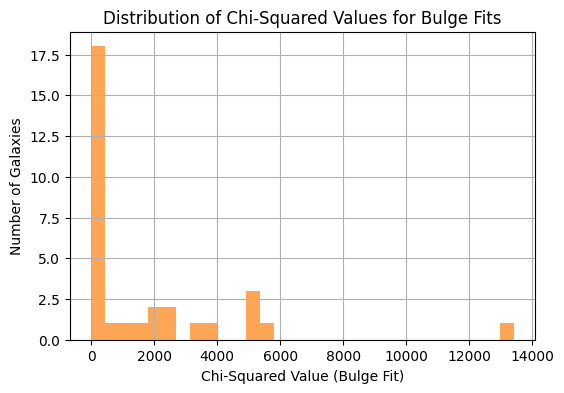

In [27]:
# plot the chisqr values for disk+gas vs bulge fits
plt.figure(figsize=(6,4))

chi2 = bulge_data["ChiSq_bulge"].values
# chi2 = np.where(chi2 > 100, np.nan, chi2)  # Replace zero values with a small number for log scale

plt.hist(chi2, bins=30, color='C1', alpha=0.7)
plt.xlabel('Chi-Squared Value (Bulge Fit)')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of Chi-Squared Values for Bulge Fits')
plt.grid()
# plt.xscale('log')
plt.show()


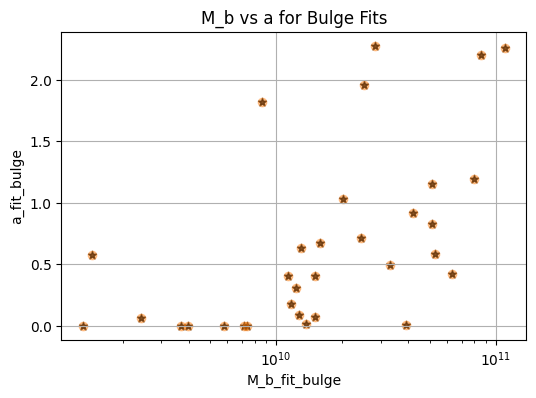

In [17]:
# plot Mb and a for disk gas and bulge fits
bulge_data = pd.read_csv(data_path + "hernquist_fits_disk_gas_bulge.csv")
bulge_data_log = pd.read_csv(data_path + "hernquist_fits_disk_gas_bulge_log.csv")

plt.figure(figsize=(6,4))

plt.scatter(bulge_data["M_b_fit_bulge"].values, bulge_data["a_fit_bulge"].values, color='k', marker='*', alpha=0.8)
plt.scatter(bulge_data_log["M_b_fit_bulge"].values, bulge_data_log["a_fit_bulge"].values, color='C1', alpha=0.4)
plt.xlabel('M_b_fit_bulge')
plt.ylabel('a_fit_bulge')
plt.title('M_b vs a for Bulge Fits')
plt.grid()
plt.xscale('log')
# plt.yscale('log')
plt.show()

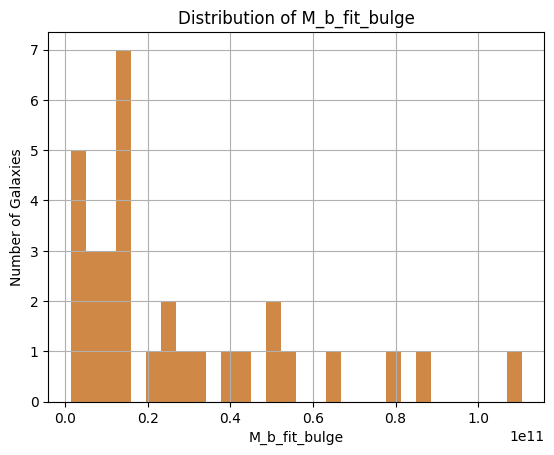

In [11]:
plt.hist(bulge_data["M_b_fit_bulge"].values, bins=30, color='C0', alpha=0.7)
plt.hist(bulge_data_log["M_b_fit_bulge"].values, bins=30, color='C1', alpha=0.7)
plt.xlabel('M_b_fit_bulge')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of M_b_fit_bulge')
plt.grid()
# plt.xscale('log')
plt.show()

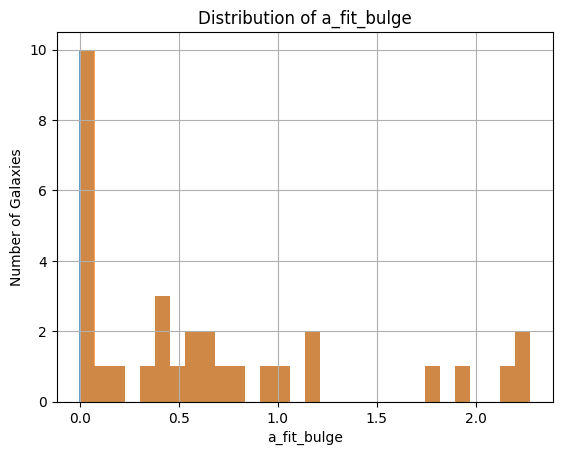

In [12]:
plt.hist(bulge_data["a_fit_bulge"].values, bins=30, color='C0', alpha=0.7)
plt.hist(bulge_data_log["a_fit_bulge"].values, bins=30, color='C1', alpha=0.7)
plt.xlabel('a_fit_bulge')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of a_fit_bulge')
plt.grid()
# plt.xscale('log')
plt.show()

In [6]:
print(len(bulge_data))
print(len(bulge_data_log))

32
32


In [34]:
max_a = bulge_data["a_fit_bulge"].values.max()

gid_max_a = bulge_data[bulge_data["a_fit_bulge"] == max_a]["GalaxyID"].values[0]

print(f"Galaxy with largest a_fit_bulge: {gid_max_a} with a_fit_bulge = {max_a}")

Galaxy with largest a_fit_bulge: NGC4217 with a_fit_bulge = 2.2754076229727467


# Plot the chi squared results

Number of galaxies with failed fits: 46


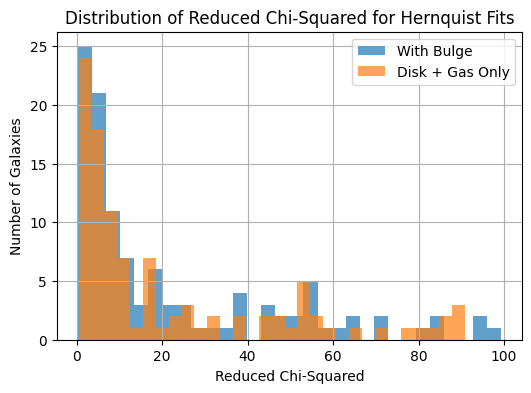

In [4]:
plot_path = os.getcwd() + "/plots/fits/"
data_path = os.getcwd() + "/data/fit_data/"

data = pd.read_csv(os.path.join(data_path, "hernquist_fit_results_gamma.csv"))
data2 = pd.read_csv(os.path.join(data_path, "hernquist_fit_disk_gas.csv"))
failed = np.loadtxt(os.path.join(data_path, "failed_fits_gamma.txt"), dtype=str).tolist()
print("Number of galaxies with failed fits:", len(failed))

sub = data[data["RedChiSq"] < 100]
sub2 = data2[data2["RedChiSq"] < 100]

plt.figure(figsize=(6,4))
plt.hist(sub["RedChiSq"], bins=30, color='C0', alpha=0.7, label='With Bulge')
plt.hist(sub2["RedChiSq"], bins=30, color='C1', alpha=0.7, label='Disk + Gas Only')
plt.legend()  
plt.xlabel('Reduced Chi-Squared')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of Reduced Chi-Squared for Hernquist Fits')
plt.grid()
plt.show()

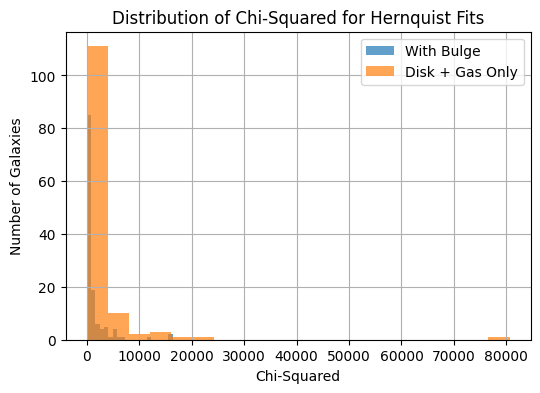

In [5]:
plt.figure(figsize=(6,4))
plt.hist(data["ChiSq"], bins=20, color='C0', alpha=0.7, label='With Bulge')  
plt.hist(data2["ChiSq"], bins=20, color='C1', alpha=0.7, label='Disk + Gas Only')
plt.legend()
plt.xlabel('Chi-Squared')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of Chi-Squared for Hernquist Fits')
plt.grid()
plt.show()

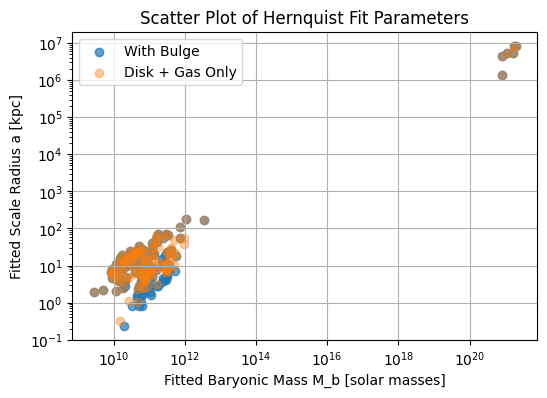

In [7]:
# scatter of M_b and a fits

plt.figure(figsize=(6,4))
plt.scatter(data["M_b_fit"], data["a_fit"], color='C0', alpha=0.7, label='With Bulge')
plt.scatter(data2["M_b_fit"], data2["a_fit"], color='C1', alpha=0.4, label='Disk + Gas Only')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Fitted Baryonic Mass M_b [solar masses]')
plt.ylabel('Fitted Scale Radius a [kpc]')
plt.title('Scatter Plot of Hernquist Fit Parameters')
plt.legend()
plt.grid()
plt.show()

Check the cluster at high mass

# Mass-to-Light Ratio 

In [ ]:
# path = os.getcwd() + "/data/fit_data/"

# results = []

# for galaxy_id in galaxy_ids:
#     g_disk, e_disk = Gamma_disk(galaxy_id)
#     g_bulg, e_bulg = Gamma_bulge(galaxy_id)
    
#     results.append([galaxy_id, g_disk, e_disk, g_bulg, e_bulg])
    
# results_df = pd.DataFrame(results, columns=["GalaxyID", "Gamma_disk", "Error_disk", "Gamma_bulge", "Error_bulge"])
# results_df.to_csv(os.path.join(path, "gamma_fits.csv"), index=False)

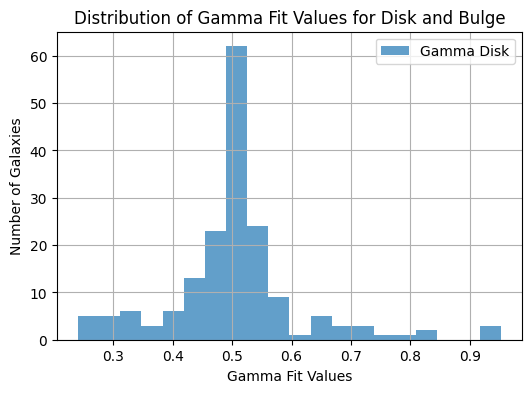

In [14]:
data = pd.read_csv(data_path + "gamma_fits.csv")

plt.figure(figsize=(6,4))
plt.hist(data["Gamma_disk"], bins=20, color='C0', alpha=0.7)
# plt.hist(data["Gamma_bulge"], bins=30, color='C1', alpha=0.7)
plt.xlabel('Gamma Fit Values')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of Gamma Fit Values for Disk and Bulge')
plt.legend(['Gamma Disk', 'Gamma Bulge'])
plt.grid()
plt.show()

In [15]:
len(data)

175

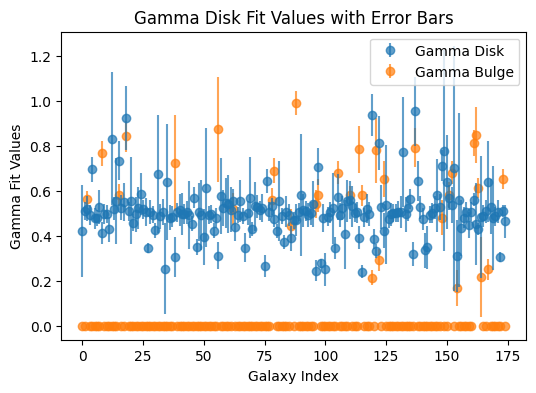

In [5]:
plt.figure(figsize=(6,4))

plt.errorbar(data["GalaxyID"].index, data["Gamma_disk"], yerr=data["Error_disk"], fmt='o', label='Gamma Disk', color='C0', alpha=0.7, zorder=3)
plt.errorbar(data["GalaxyID"].index, data["Gamma_bulge"], yerr=data["Error_bulge"], fmt='o', label='Gamma Bulge', color='C1', alpha=0.7, zorder=0)
plt.ylabel('Gamma Fit Values')
plt.xlabel('Galaxy Index')
plt.title('Gamma Disk Fit Values with Error Bars')
plt.legend()
plt.show()

# Compare M_b from fits and M_b from rotation curve data

In [5]:
data_path = os.getcwd() + "/data/fit_data/"

galaxy_id = "F571-8"

M_b, err_Mb = get_Mb_data(galaxy_id)
print(f"Galaxy {galaxy_id} Baryonic Mass M_b: {M_b:.2e} ± {err_Mb:.2e} solar masses")

Galaxy F571-8 Baryonic Mass M_b: 4.92e+09 ± 7.41e+08 solar masses


In [7]:
dfit = pd.read_csv(data_path + "hernquist_fit_results_gamma.csv")
df = dfit[dfit["GalaxyID"] == galaxy_id]
M_b_fit = df["M_b_fit"].values[0]
print(f"Galaxy {galaxy_id} Fitted Baryonic Mass M_b_fit: {M_b_fit:.2e} solar masses")

Galaxy F571-8 Fitted Baryonic Mass M_b_fit: 5.08e+09 solar masses


In [8]:
dfit = pd.read_csv(data_path + "hernquist_fit_results_gamma.csv")

results = []

for galaxy_id in galaxy_ids:
    try:
        df = dfit[dfit["GalaxyID"] == galaxy_id]
        M_b_fit = np.log10(df["M_b_fit"].values[0])
        M_b, err_Mb = get_Mb_data(galaxy_id)
        M_b = np.log10(M_b)
    except:
        continue
    
    results.append((galaxy_id, M_b_fit, M_b))
    
results_df = pd.DataFrame(results, columns=["GalaxyID", "log_M_b_fit", "log_M_b"])
results_df.to_csv(os.path.join(data_path, "M_b_comparison.csv"), index=False)

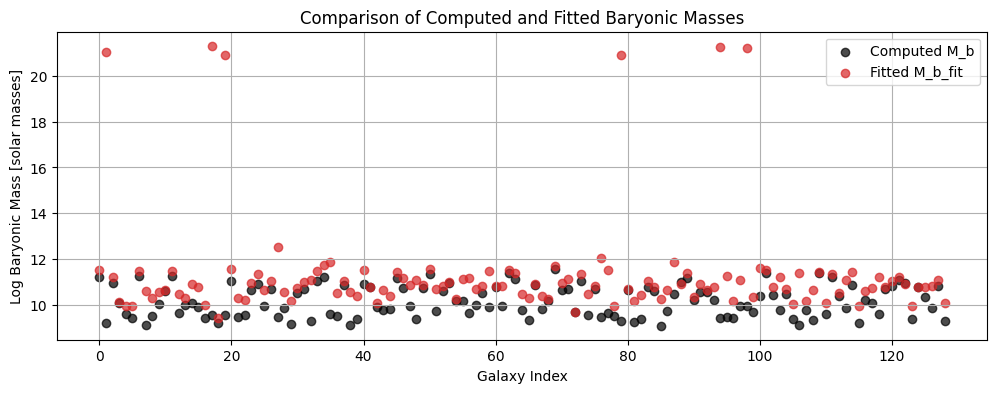

In [10]:
data = pd.read_csv(os.path.join(data_path, "M_b_comparison.csv"))

idx = np.arange(len(data))

plt.figure(figsize=(12,4))
plt.scatter(idx, data["log_M_b"], label='Computed M_b', color='k', alpha=0.7)
plt.scatter(idx, data["log_M_b_fit"], label='Fitted M_b_fit', color='C3', alpha=0.7)
plt.xlabel('Galaxy Index')
plt.ylabel('Log Baryonic Mass [solar masses]')
plt.title('Comparison of Computed and Fitted Baryonic Masses')
plt.legend()
plt.grid()
plt.show()

The fitted Masses are consistently higher than the computed. This may be due to the fact that I neglected to include the bulge mass in the computed mass. 

In [12]:
df, _, _ = get_rc_data('F571-8')
df.head()

,Rad,Vobs,errV,Vgas,Vdisk,Vbul,SBdisk,SBbul
0,0.22,12.4,7.0,0.92,38.29,0.0,1846.57,0.0
1,0.78,37.5,4.0,2.67,85.69,0.0,705.48,0.0
2,1.33,56.5,4.0,3.90,104.00,0.0,403.21,0.0
3,2.33,69.1,4.0,5.34,114.45,0.0,121.25,0.0
4,3.44,85.5,7.5,7.09,107.32,0.0,35.98,0.0


In [13]:
gid_bulge = []
gid_nobulge = []

for galaxy_id in galaxy_ids:
    df, _, _ = get_rc_data(galaxy_id)
    bul = df["Vbul"].values[0]
    if np.sum(bul) > 0:
        gid_bulge.append(galaxy_id)
    else:
        gid_nobulge.append(galaxy_id)
print("Galaxies with bulge:", len(gid_bulge))
print("Galaxies without bulge:", len(gid_nobulge))

Galaxies with bulge: 32
Galaxies without bulge: 143


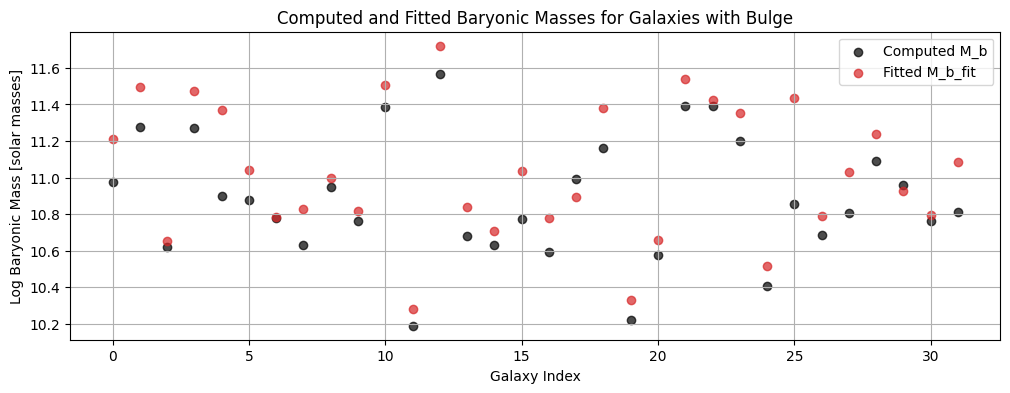

In [14]:
# for galaxies with bulge

data = pd.read_csv(os.path.join(data_path, "M_b_comparison.csv"))

data = data[data["GalaxyID"].isin(gid_bulge)]

idx = np.arange(len(data))

plt.figure(figsize=(12,4))
plt.scatter(idx, data["log_M_b"], label='Computed M_b', color='k', alpha=0.7)
plt.scatter(idx, data["log_M_b_fit"], label='Fitted M_b_fit', color='C3', alpha=0.7)
plt.xlabel('Galaxy Index')
plt.ylabel('Log Baryonic Mass [solar masses]')
plt.title('Computed and Fitted Baryonic Masses for Galaxies with Bulge')
plt.legend()
plt.grid()
plt.show()

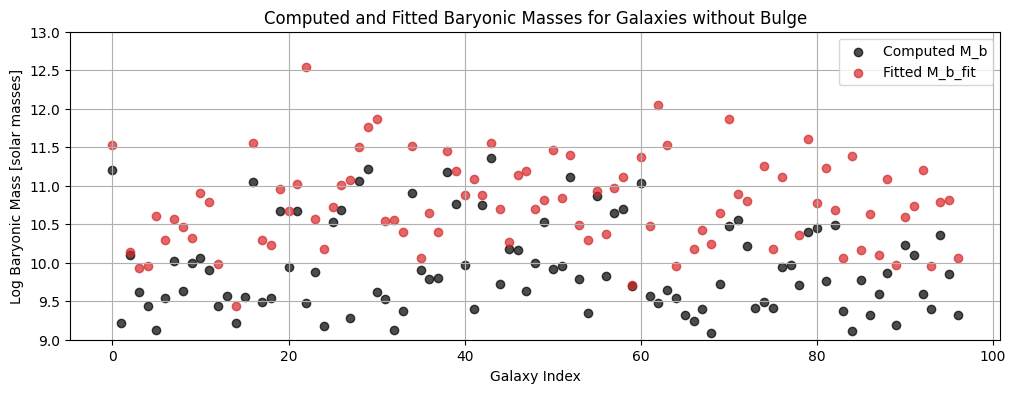

In [17]:
# for galaxies without bulge
data = pd.read_csv(os.path.join(data_path, "M_b_comparison.csv"))

data = data[data["GalaxyID"].isin(gid_nobulge)]

idx = np.arange(len(data))

plt.figure(figsize=(12,4))
plt.scatter(idx, data["log_M_b"], label='Computed M_b', color='k', alpha=0.7)
plt.scatter(idx, data["log_M_b_fit"], label='Fitted M_b_fit', color='C3', alpha=0.7)
plt.xlabel('Galaxy Index')
plt.ylabel('Log Baryonic Mass [solar masses]')
plt.title('Computed and Fitted Baryonic Masses for Galaxies without Bulge')
plt.legend()
plt.grid()
plt.ylim(9,13)
plt.show()

Fitted M_b is systematically larger, even for galaxies without a bulge componenet. 

# Checking new log generated data with no failed galaxies 

In [ ]:
data_path = os.getcwd() + "/data/fit_data/"

df = pd.read_csv(data_path + "hern_fits.csv")

df.head()

,GalaxyID,M_b_fit,a_fit,ChiSq,M_b_fit_bulge,a_fit_bulge,ChiSq_bulge
0,NGC5371,3.379071e+11,1.071828e+01,5220.849667,NaN,NaN,NaN
1,UGC05829,5.878777e+25,1.252024e+09,182.817597,NaN,NaN,NaN
2,NGC5005,3.038742e+11,7.392089e+00,1667.229288,1.502302e+10,0.407524,1970.014208
3,UGCA444,6.685486e+09,1.321018e+01,133.680930,NaN,NaN,NaN
4,NGC1003,1.379918e+10,3.716878e+00,364.923466,NaN,NaN,NaN


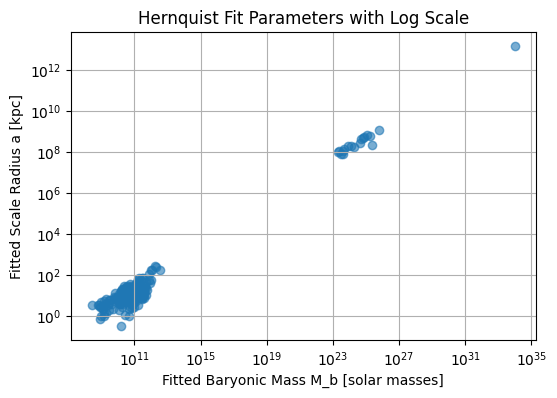

In [6]:
plt.figure(figsize=(6,4))

plt.scatter(df["M_b_fit"].values, df["a_fit"].values, color='C0', alpha=0.6)
plt.xlabel('Fitted Baryonic Mass M_b [solar masses]')
plt.ylabel('Fitted Scale Radius a [kpc]')
plt.title('Hernquist Fit Parameters with Log Scale')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.show()

In [15]:
dfit = pd.read_csv(data_path + "hern-fits.csv")

results = []

for galaxy_id in galaxy_ids:
    try:
        df = dfit[dfit["GalaxyID"] == galaxy_id]
        M_b_fit = np.log10(df["M_b_fit"].values[0])
        M_b, err_Mb = get_Mb_data(galaxy_id)
        M_b = np.log10(M_b)
    except:
        continue
    
    results.append((galaxy_id, M_b_fit, M_b))
    
results_df = pd.DataFrame(results, columns=["GalaxyID", "log_M_b_fit", "log_M_b"])
results_df.to_csv(os.path.join(data_path, "M_b_comparison.csv"), index=False)

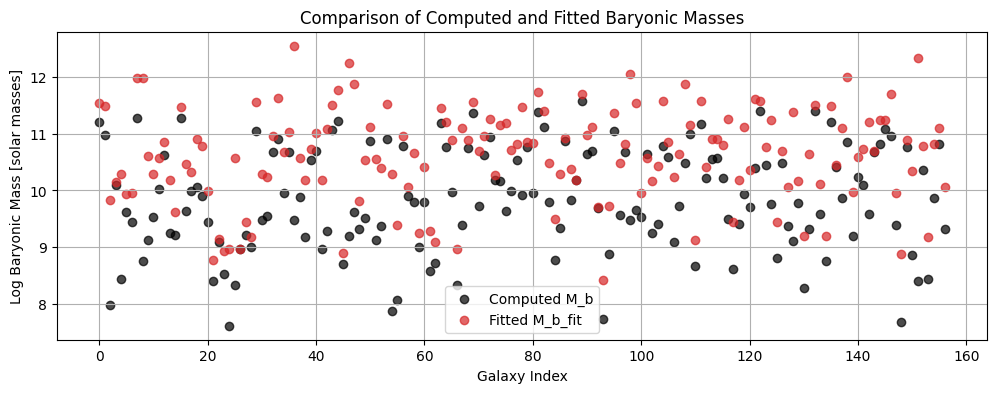

In [18]:
data = pd.read_csv(os.path.join(data_path, "M_b_comparison.csv"))

data = data[data['log_M_b_fit'] < 20]

idx = np.arange(len(data))

plt.figure(figsize=(12,4))
plt.scatter(idx, data["log_M_b"], label='Computed M_b', color='k', alpha=0.7)
plt.scatter(idx, data["log_M_b_fit"], label='Fitted M_b_fit', color='C3', alpha=0.7)
plt.xlabel('Galaxy Index')
plt.ylabel('Log Baryonic Mass [solar masses]')
plt.title('Comparison of Computed and Fitted Baryonic Masses')
plt.legend()
plt.grid()
plt.show()

Number of galaxies in comparison: 157


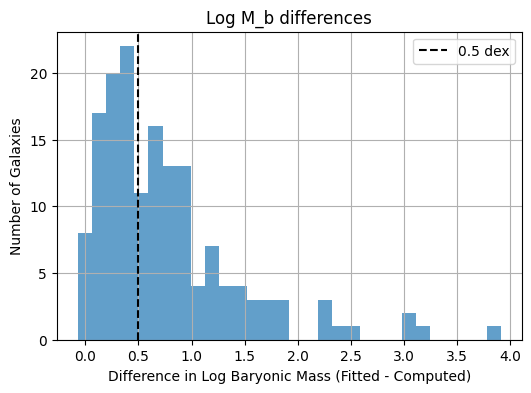

In [32]:
# hist of the differences between computed and fitted M_b values
data = pd.read_csv(os.path.join(data_path, "M_b_comparison.csv"))
data = data[data['log_M_b_fit'] < 20]
print("Number of galaxies in comparison:", len(data))
data["M_b_diff"] = data["log_M_b_fit"] - data["log_M_b"]

plt.figure(figsize=(6,4))
plt.hist(data["M_b_diff"], bins=30, color='C0', alpha=0.7)
plt.axvline(0.5, color='k', linestyle='--', label='0.5 dex')
plt.xlabel('Difference in Log Baryonic Mass (Fitted - Computed)')
plt.ylabel('Number of Galaxies')
plt.title('Log M_b differences')
plt.legend()
plt.grid()
plt.show()

In [29]:
len(data[data["M_b_diff"] <= 0.5])

68